# Puls-Kandidat: Dispersion, DM-Time und Dedispersion

Dieses Notebook erzeugt eine Abbildung mit drei quadratischen Teilplots für denselben Puls. Ändere nur `PULSE_INDEX` in der folgenden Zelle und führe anschließend alle Zellen aus. Die Metadaten des gewählten Pulses werden **außerhalb** der Abbildung ausgegeben.

`PULSE_INDEX` zählt nur Pulse im gewählten Dataset-Split (`train`, `val` oder `test`), absteigend nach SNR sortiert; Artefakte werden nicht angeboten.

In [13]:
# --- Auswahl des Pulses -----------------------------------------------------
SPLIT = 'train'          # 'train', 'val' oder 'test'
PULSE_INDEX = 4         # 0 = Puls mit der höchsten SNR im gewählten Split
PATCH_WIDTH = 256       # Muss zur erzeugten Dataset-Auflösung passen


In [14]:
from pathlib import Path
import bisect
import json
import struct

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Das Notebook funktioniert sowohl bei Start aus dem Workspace als auch aus WP2-1.
cwd = Path.cwd().resolve()
PROJECT_DIR = cwd if (cwd / 'DM_time_dataset_creator').is_dir() else cwd / 'WP2-1'
if not (PROJECT_DIR / 'DM_time_dataset_creator').is_dir():
    raise FileNotFoundError('WP2-1/DM_time_dataset_creator wurde nicht gefunden.')

WORKSPACE_DIR = PROJECT_DIR.parent
OUTPUT_DIR = PROJECT_DIR / 'DM_time_dataset_creator' / 'outputs'
PREFIX = 'B0531+21_59000_48386'
FILTERBANK_PATH = WORKSPACE_DIR / 'Andrei' / f'{PREFIX}.fil'

if SPLIT not in {'train', 'val', 'test'}:
    raise ValueError("SPLIT muss 'train', 'val' oder 'test' sein.")
if not FILTERBANK_PATH.is_file():
    raise FileNotFoundError(f'Filterbank-Datei nicht gefunden: {FILTERBANK_PATH}')

labels = np.load(OUTPUT_DIR / f'{PREFIX}_DM_time_dataset_realbased_labels_{SPLIT}.npy', mmap_mode='r')
metadata = np.load(OUTPUT_DIR / f'{PREFIX}_DM_time_dataset_realbased_metadata_{SPLIT}.npy', mmap_mode='r')

def load_sharded_sample(manifest_path, sample_index):
    """Lädt genau einen Kandidaten aus einem Shard, ohne das ganze Dataset in den RAM zu laden."""
    manifest_path = Path(manifest_path)
    with manifest_path.open(encoding='utf-8') as handle:
        manifest = json.load(handle)
    if not 0 <= sample_index < manifest['total_samples']:
        raise IndexError(f'Index {sample_index} liegt außerhalb von 0 … {manifest["total_samples"] - 1}.')
    starts = [entry['start_sample'] for entry in manifest['shards']]
    shard_number = bisect.bisect_right(starts, sample_index) - 1
    shard = manifest['shards'][shard_number]
    local_index = sample_index - shard['start_sample']
    array = np.load(manifest_path.parent / shard['path'], mmap_mode='r')
    return np.array(array[local_index])

def _read_sigproc_string(handle):
    size_bytes = handle.read(4)
    if len(size_bytes) != 4:
        raise EOFError('Unerwartetes Ende im SIGPROC-Header.')
    size = struct.unpack('<i', size_bytes)[0]
    return handle.read(size).decode('ascii')

def read_sigproc_header(path):
    """Liest die für diesen 8-bit-SIGPROC-Filterbankdatensatz benötigten Headerfelder."""
    int_keys = {'telescope_id', 'machine_id', 'data_type', 'nchans', 'nbeams', 'ibeam',
                'nbits', 'nifs', 'barycentric', 'pulsarcentric', 'nsamples'}
    double_keys = {'src_raj', 'src_dej', 'az_start', 'za_start', 'fch1', 'foff',
                   'tstart', 'tsamp', 'refdm', 'period'}
    string_keys = {'rawdatafile', 'source_name'}
    header = {}
    with Path(path).open('rb') as handle:
        if _read_sigproc_string(handle) != 'HEADER_START':
            raise ValueError('Keine SIGPROC-Filterbankdatei (HEADER_START fehlt).')
        while True:
            key = _read_sigproc_string(handle)
            if key == 'HEADER_END':
                return header, handle.tell()
            if key in int_keys:
                header[key] = struct.unpack('<i', handle.read(4))[0]
            elif key in double_keys:
                header[key] = struct.unpack('<d', handle.read(8))[0]
            elif key in string_keys:
                header[key] = _read_sigproc_string(handle)
            else:
                raise ValueError(f'Unbekanntes SIGPROC-Headerfeld: {key}')

def load_dispersed_filterbank_patch(path, start_sample, width):
    """Lädt einen unverschobenen Frequency-Time-Ausschnitt (Frequenz × Zeit)."""
    header, data_offset = read_sigproc_header(path)
    if header['nbits'] != 8 or header['nifs'] != 1:
        raise ValueError('Dieses Notebook erwartet 8-bit-Daten mit genau einer Polarisation.')
    nchans = header['nchans']
    file_size = Path(path).stat().st_size
    available = (file_size - data_offset) // nchans
    start_sample = int(np.clip(start_sample, 0, max(0, available - width)))
    with Path(path).open('rb') as handle:
        handle.seek(data_offset + start_sample * nchans)
        raw = np.fromfile(handle, dtype=np.uint8, count=width * nchans)
    if raw.size != width * nchans:
        raise ValueError('Der gewünschte Ausschnitt liegt außerhalb der Filterbankdaten.')
    return raw.reshape(width, nchans).T, header, start_sample

dm_manifest = OUTPUT_DIR / 'dm_time_shards' / SPLIT / f'{PREFIX}_DM_time_dataset_manifest.json'
freq_manifest = OUTPUT_DIR / 'dedispersed_freq_time_shards' / SPLIT / f'{PREFIX}_dedispersed_freq_time_manifest.json'
if len(labels) != len(metadata):
    raise ValueError('Labels und Metadaten haben unterschiedliche Längen.')


In [15]:
# Nur Pulse sind auswählbar; Metadaten erscheinen separat (nicht Teil des Plots).
pulse_dataset_indices = np.flatnonzero(labels == 'Pulse')
pulse_snrs = metadata[pulse_dataset_indices, 0]
# np.nan_to_num sorgt dafür, dass Pulse ohne SNR ans Ende der Auswahl kommen.
pulse_dataset_indices = pulse_dataset_indices[np.argsort(np.nan_to_num(pulse_snrs, nan=-np.inf))[::-1]]
if not 0 <= PULSE_INDEX < len(pulse_dataset_indices):
    raise IndexError(f'PULSE_INDEX muss zwischen 0 und {len(pulse_dataset_indices) - 1} liegen.')
CANDIDATE_INDEX = int(pulse_dataset_indices[PULSE_INDEX])

candidate_label = str(labels[CANDIDATE_INDEX])
snr, t_min_s, t_max_s, dm_pc_cm3, numeric_class = metadata[CANDIDATE_INDEX]

display(pd.DataFrame([{
    'Pulsindex': PULSE_INDEX,
    'Dataset-Index': CANDIDATE_INDEX,
    'Klasse': candidate_label,
    'SNR': snr,
    'DM [pc cm$^{-3}$]': dm_pc_cm3,
    'Zeitfenster [s]': f'{t_min_s:.6f} – {t_max_s:.6f}',
}]))

dm_time = load_sharded_sample(dm_manifest, CANDIDATE_INDEX)
dedispersed_freq_time = load_sharded_sample(freq_manifest, CANDIDATE_INDEX)

# Der Roh-Ausschnitt enthält zusätzlich die volle Dispersionsverzögerung über das Band.
# Seine Mitte ist auf die Mitte des Zeitfensters aus den Metadaten ausgerichtet.
filterbank_header, _ = read_sigproc_header(FILTERBANK_PATH)
centre_sample = int(round(0.5 * (t_min_s + t_max_s) / filterbank_header['tsamp']))
frequencies_mhz = filterbank_header['fch1'] + np.arange(filterbank_header['nchans']) * filterbank_header['foff']
delay_seconds = 4.148808e3 * dm_pc_cm3 * (frequencies_mhz**-2 - frequencies_mhz.max()**-2)
max_delay_bins = int(np.rint(delay_seconds / filterbank_header['tsamp']).max())
raw_window_width = PATCH_WIDTH + max_delay_bins
# Bei diesem Start liegt die Mitte des dispersierten Sweeps in der Mitte des Bildes.
raw_start = centre_sample - PATCH_WIDTH // 2
dispersed_freq_time, filterbank_header, raw_start = load_dispersed_filterbank_patch(
    FILTERBANK_PATH, raw_start, raw_window_width
)

if dm_time.shape != dedispersed_freq_time.shape:
    raise ValueError(f'Inkonsistente Patchformen: DM-Time {dm_time.shape}, Frequency-Time {dedispersed_freq_time.shape}.')

,Pulsindex,Dataset-Index,Klasse,SNR,DM [pc cm$^{-3}$],Zeitfenster [s]
0,4,39462,Pulse,72.1,57.0,991.949107 – 991.975322


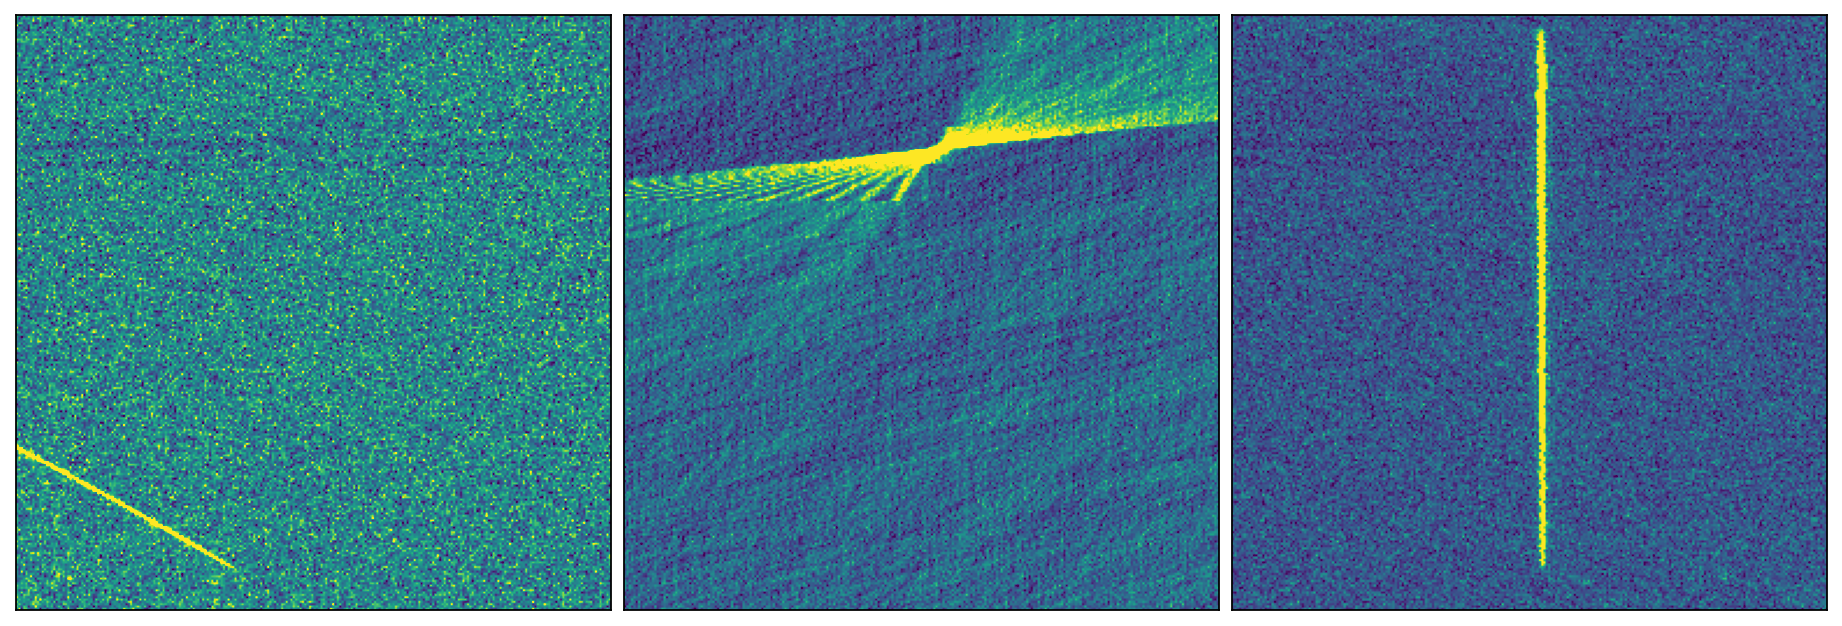

In [24]:
def display_limits(image, percentiles=(1, 99)):
    lo, hi = np.nanpercentile(image, percentiles)
    return (lo, hi) if hi > lo else (lo, lo + 1)

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'figure.dpi': 160,
})

# Der dispersierte Ausschnitt ist entlang der Zeitachse gespiegelt, damit der
# Dispersionsverlauf der gewünschten Konvention entspricht.
panels = [
    dispersed_freq_time[:, ::-1],
    dm_time,
    dedispersed_freq_time,
]
y_axis_labels = ['Frequency channel', 'DM trial', 'Frequency channel']

fig, axes = plt.subplots(1, 3, figsize=(11.4, 4.0), constrained_layout=True)
for ax, image, ylabel in zip(axes, panels, y_axis_labels):
    vmin, vmax = display_limits(image)
    ax.imshow(image, origin='lower', aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_box_aspect(1)
    ax.set_xlabel('Time bin')
    ax.set_ylabel(ylabel)
    ax.tick_params(direction='out', top=False, right=False)

# Die Kandidateninformation steht bewusst nur in der Ausgabe der vorherigen Zelle.
plt.show()

# Optional für die Thesis-Ausgabe:
# fig.savefig('pulse_candidate_triptych.pdf', bbox_inches='tight')
# fig.savefig('pulse_candidate_triptych.png', dpi=300, bbox_inches='tight')